In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ensambles = 3000
M1 = np.empty((10, ensambles))
for idx in range(10):
    with open('./results/{0}_{1}_fig14y15_rho_critical.p'.format(1000000, idx), "rb") as f:
        mags = pickle.load(f)
        M1[idx] = mags

In [4]:
ensambles = 3000
M2 = np.empty((10, ensambles))
for idx in range(10, 20):
    with open('./results/{0}_{1}_fig14y15_rho_critical.p'.format(1000000, idx), "rb") as f:
        mags = pickle.load(f)
        M2[idx-10] = mags

In [5]:
Nnu = 656
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.108021+10/Nnu
min_new = 0.108021-10/Nnu
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

In [6]:
m0 = 0.171405
cutoff = m0
gamma = 1.47
nu = 2.13
N = 1e6
kc = 0.108021
pairs = []
for idx in range(10):
    X = N*(np.mean(M1[idx][M1[idx] < cutoff]**2)-np.mean(M1[idx][M1[idx] < cutoff])**2)
    pairs.append([(kc - kappa_range[idx])*N**(1/nu), X*N**(-gamma/nu)])

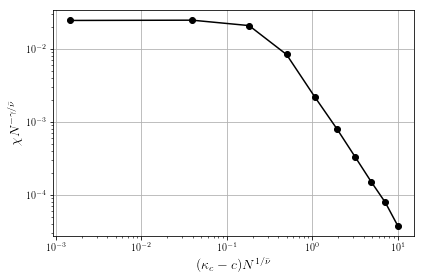

In [7]:
plt.rc('text', usetex=True)
plt.loglog(*np.array(pairs).T, 'ko', ls='-')
plt.xlabel(r'$(\kappa_c - c)N^{1/\bar{\nu}}$', fontsize=14)
plt.ylabel(r'$\chi N^{-\gamma/\bar{\nu}}$', fontsize=14)
plt.grid()
plt.tight_layout()
plt.savefig('fig14_1Mnodos_3ksamples.pdf', dpi=300)

In [11]:
pairs2 = []
for idx in range(10):
    X = N*(np.mean(M2[idx][M2[idx] > cutoff]**2)-np.mean(M2[idx][M2[idx] > cutoff])**2)
    pairs2.append([(-kc + kappa_range[idx+10])*N**(1/nu), X*N**(-gamma/nu)])

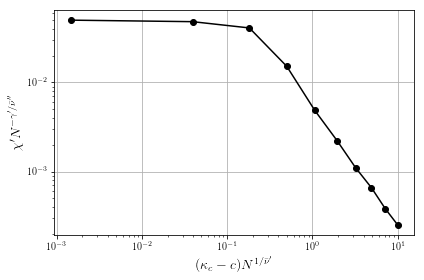

In [12]:
plt.loglog(*np.array(pairs2).T, 'ko', ls='-')
plt.xlabel(r"$(\kappa_c - c)N^{1/\bar{\nu}'}$", fontsize=14)
plt.ylabel(r"$\chi' N^{-\gamma'/\bar{\nu}''}$", fontsize=14)
plt.grid()
plt.tight_layout()
plt.savefig('fig15_1Mnodos_3ksamples.pdf', dpi=300)